Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Dataset Ready
Found 2787 images belonging to 2 classes.
Found 858 images belonging to 2 classes.
Found 856 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 151s 2s/step - accuracy: 0.5358 - loss: 0.7706 - val_accuracy: 0.6515 - val_loss: 0.6205
Epoch 2/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 146s 2s/step - accuracy: 0.6041 - loss: 0.6561 - val_accuracy: 0.6457 - val_loss: 0.6102
Epoch 3/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 145s 2s/step - accuracy: 0.6590 - loss: 0.6077 - val_accuracy: 0.6807 - val_loss: 0.5997
Epoch 4/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 204s 2s/step - accuracy: 0.6620 - loss: 0.6097 - val_accuracy: 0.6772 - val_loss: 0.5941
Epoch 5/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.6547 - loss: 0.6027 - val_accuracy: 0.7005 - val_loss: 0.5886
Epoch 6/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 135s 2s/step - accuracy: 0.6662 - loss: 0.5850 - val_accuracy: 0.6958 - val_loss: 0.5825
Epoch 7/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 152s 2s/step - accuracy: 0.6694 - loss: 0.5946 - val_accuracy: 0.6970 - val_loss: 0.5792
Epoch 8/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.6834 - loss: 0.5694 - val_accuracy: 0.7121 - v

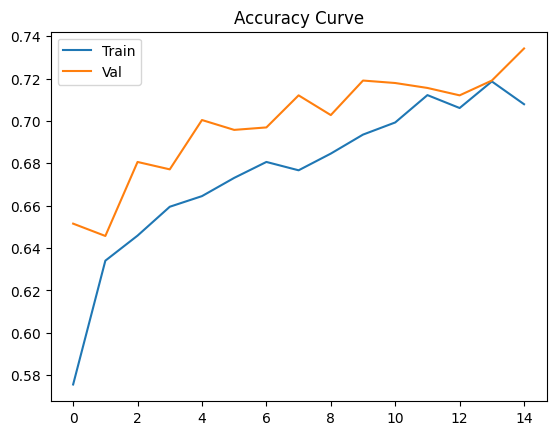

856/856 ━━━━━━━━━━━━━━━━━━━━ 33s 39ms/step - accuracy: 0.7148 - loss: 0.4998
Test Accuracy: 0.7231308221817017
856/856 ━━━━━━━━━━━━━━━━━━━━ 33s 37ms/step


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

[[279 147]
 [ 90 340]]
              precision    recall  f1-score   support

           0       0.76      0.65      0.70       426
           1       0.70      0.79      0.74       430

    accuracy                           0.72       856
   macro avg       0.73      0.72      0.72       856
weighted avg       0.73      0.72      0.72       856



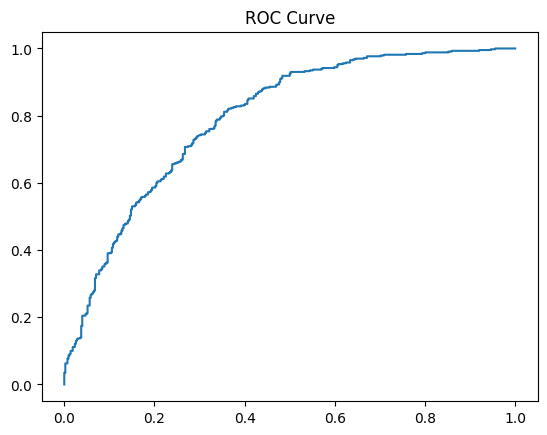

ROC-AUC: 0.7932470793754778
✅ Misclassified images saved
✅ Model saved to Drive


In [1]:
# ================= MOUNT DRIVE =================
from google.colab import drive
drive.mount('/content/drive')

# ================= IMPORTS =================
import os, shutil, random
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
from google.colab import files

# ================= PATHS =================
SOURCE_DIR = "/content/drive/MyDrive/combinedataset/combinedataset"
TARGET_DIR = "/content/dataset"

classes = ["fibroid", "non_fibroid"]

# ================= SPLIT DATASET =================
split_ratio = {"train":0.7, "val":0.15, "test":0.15}

for split in split_ratio:
    for cls in classes:
        os.makedirs(os.path.join(TARGET_DIR, split, cls), exist_ok=True)

for cls in classes:
    images = os.listdir(os.path.join(SOURCE_DIR, cls))
    random.shuffle(images)

    n = len(images)
    train_end = int(0.7*n)
    val_end = int(0.85*n)

    splits = {
        "train": images[:train_end],
        "val": images[train_end:val_end],
        "test": images[val_end:]
    }

    for split, imgs in splits.items():
        for img in imgs:
            shutil.copy(
                os.path.join(SOURCE_DIR, cls, img),
                os.path.join(TARGET_DIR, split, cls, img)
            )

print("✅ Dataset Ready")

# ================= DATA GENERATORS =================
IMG_SIZE = 224
BATCH_SIZE = 32

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True
).flow_from_directory(
    TARGET_DIR+"/train",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    TARGET_DIR+"/val",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    TARGET_DIR+"/test",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=1,
    class_mode='binary',
    shuffle=False
)

# ================= MODEL =================
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ================= TRAIN =================
EPOCHS = 15
history = model.fit(train_gen, validation_data=val_gen, epochs=EPOCHS)

# ================= TRAINING GRAPH =================
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train','Val'])
plt.title("Accuracy Curve")
plt.show()

# ================= TEST EVALUATION =================
test_loss, test_acc = model.evaluate(test_gen)
print("Test Accuracy:", test_acc)

# ================= PREDICTIONS =================
y_true = test_gen.classes
y_prob = model.predict(test_gen).ravel()
y_pred = (y_prob > 0.5).astype(int)

label_map = {v:k for k,v in test_gen.class_indices.items()}

actual_labels = [label_map[i] for i in y_true]
predicted_labels = [label_map[i] for i in y_pred]

# ================= RISK CATEGORY =================
def risk_category(p):
    if p < 0.30:
        return "Low Risk"
    elif p < 0.70:
        return "Moderate Risk"
    else:
        return "High Risk"

risk_levels = [risk_category(p) for p in y_prob]

# ================= CREATE CSV =================
results_df = pd.DataFrame({
    "Image_Name": test_gen.filenames,
    "Actual_Label": actual_labels,
    "Predicted_Label": predicted_labels,
    "Fibroid_Probability": y_prob,
    "Risk_%": y_prob*100,
    "Risk_Level": risk_levels
})

results_df.to_csv("Fibroid_Test_Predictions.csv", index=False)

files.download("Fibroid_Test_Predictions.csv")

# ================= CONFUSION MATRIX =================
print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))

# ================= ROC CURVE =================
fpr, tpr, _ = roc_curve(y_true, y_prob)
plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.show()

print("ROC-AUC:", roc_auc_score(y_true, y_prob))

# ================= SAVE MISCLASSIFIED IMAGES =================
os.makedirs("/content/misclassified", exist_ok=True)

for i in range(len(y_true)):
    if y_true[i] != y_pred[i]:
        src = os.path.join(TARGET_DIR+"/test", test_gen.filenames[i])
        dst = os.path.join("/content/misclassified", os.path.basename(test_gen.filenames[i]))
        shutil.copy(src, dst)

print("✅ Misclassified images saved")

# ================= SAVE MODEL TO DRIVE =================
model.save("/content/drive/MyDrive/fibroid_detection_model.h5")

print("✅ Model saved to Drive")